# 第 4 讲：LQR——在平衡性能与控制能量之间权衡

极点配置直接规定闭环动态，但有时我们更容易表达另一类愿望：滚转角必须很小、转向角不要太偏、控制动作不要太猛烈。线性二次型调节器 LQR 把这些愿望写成一个代价函数，并计算使总成本最小的状态反馈。

本讲目标：

1. 理解二次型代价 $J$；
2. 理解 $Q$、$R$ 是相对权重，不是魔法参数；
3. 使用 Bryson 规则给出可解释的初值；
4. 比较 LQR 与极点配置在初始倾斜和外扰下的表现；
5. 认识模型最优、实际最优与鲁棒性之间的区别。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np

project_root = Path.cwd()
if not (project_root / "nominal_bike_control").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from nominal_bike_control import NominalBikeController, ScaleBikeModel

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-bright")
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
chinese_font = next((name for name in ["Arial Unicode MS", "PingFang HK", "Noto Sans CJK SC", "SimHei"] if name in available_fonts), "DejaVu Sans")
plt.rcParams.update({"font.sans-serif": [chinese_font], "axes.unicode_minus": False})

control_dt = 0.02
bike = ScaleBikeModel(dt=control_dt, track_roll=False)
bike.updateSysParam(2.0, min_forw_vel=1.0)
A, B = bike.A, bike.Bu


## 1. 把设计要求写成代价函数

连续时间 LQR 最小化

$$J=\int_0^\infty(x^TQx+u^TRu)\,dt$$

这里：

- $x^TQx$ 惩罚状态偏离平衡；
- $u^TRu$ 惩罚控制动作；
- $Q$ 越重视某个状态，该状态偏差就越昂贵；
- $R$ 越大，控制动作越昂贵，控制器通常越温和。

LQR 解连续代数 Riccati 方程，最终仍得到 $u=-Kx$。区别在于 $K$ 不是由指定极点直接求出，而是由性能与能量权衡产生。只要系统满足相应条件且 $Q\succeq0,R\succ0$，闭环会稳定。

## 2. 权重首先解决量纲问题

三个状态的数值范围不同：转向角和滚转角用 rad，滚转角速度用 rad/s。若简单使用单位矩阵，隐含意思是数值同样大的三个量同等严重，但这未必符合工程要求。

Bryson 规则给出一个容易解释的初值：若状态允许最大值为 $x_{i,max}$，取 $Q_{ii}=1/x_{i,max}^2$；若控制允许最大值为 $u_{max}$，取 $R=1/u_{max}^2$。这样每一项达到允许边界时，大致贡献相同的无量纲代价。之后还需要根据仿真和硬件能力调整。

In [2]:
state_limits = np.deg2rad([30.0, 6.0, 120.0])
control_limit = 10.0  # rad/s
Q_bryson = np.diag(1.0 / state_limits**2)
R_bryson = np.array([[1.0 / control_limit**2]])
print("Bryson Q =\n", Q_bryson)
print("Bryson R =\n", R_bryson)

# 为了让本教程的控制动作更温和，下面把输入相对代价提高。
Q = np.diag([4.0, 100.0, 2.0])
R = np.array([[10.0]])
lqr_controller = NominalBikeController(
    bike.sys, method="lqr", Qc=Q, Rc=R,
    u_min=-control_limit, u_max=control_limit,
)
print("教学用 Q =\n", Q)
print("教学用 R =\n", R)
print("LQR K =", lqr_controller.K)
print("LQR 闭环极点 =", lqr_controller.closed_loop_poles)


Bryson Q =
 [[ 3.6476  0.      0.    ]
 [ 0.     91.1891  0.    ]
 [ 0.      0.      0.228 ]]
Bryson R =
 [[0.01]]
教学用 Q =
 [[  4.   0.   0.]
 [  0. 100.   0.]
 [  0.   0.   2.]]
教学用 R =
 [[10.]]
LQR K = [[9.4375 9.4625 1.8321]]
LQR 闭环极点 = [-5.9532+0.j     -3.7738+2.4644j -3.7738-2.4644j]


## 3. 只改变 R 会发生什么

保持 $Q$ 不变，逐渐增大 $R$。观察反馈增益和闭环极点怎样变化。请先做预测：控制动作更贵以后，$K$ 的幅值会变大还是变小？闭环会更快还是更慢？

In [3]:
print(" R   | K_delta  K_roll  K_roll_rate | closed-loop poles")
print("-----+-------------------------------+------------------------------")
for r_value in [0.1, 1.0, 10.0, 100.0]:
    controller = NominalBikeController(
        bike.sys, method="lqr", Qc=Q, Rc=np.array([[r_value]])
    )
    print(f"{r_value:4.1f} | {controller.K[0,0]:7.3f} "
          f"{controller.K[0,1]:7.3f} {controller.K[0,2]:11.3f} | "
          f"{controller.closed_loop_poles}")


 R   | K_delta  K_roll  K_roll_rate | closed-loop poles
-----+-------------------------------+------------------------------
 0.1 |  13.770  41.053       6.870 | [-10.9765+7.1398j -10.9765-7.1398j  -7.0536+0.j    ]
 1.0 |  11.184  17.521       3.196 | [-5.8154+4.8746j -5.8154-4.8746j -6.642 +0.j    ]
10.0 |   9.438   9.463       1.832 | [-5.9532+0.j     -3.7738+2.4644j -3.7738-2.4644j]
100.0 |   8.448   6.624       1.312 | [-5.4265 -4.2875 -1.6438]


## 4. 用相同实验比较控制器

公平比较必须使用相同的初始状态、采样周期、限幅和外扰。我们让车辆从 $3^\circ$ 初始倾角开始，并在 0.8–0.95 s 之间施加额外滚转角加速度，模拟一次短暂侧推。

这里的控制器**没有扰动观测器**。外扰只作用在被控对象上，控制器只能从状态偏差中反应。

In [4]:
def simulate_with_push(controller, A, B, duration=3.0,
                       plant_dt=0.001, control_dt=0.02):
    time = np.arange(0.0, duration + plant_dt, plant_dt)
    states = np.zeros((time.size, 3))
    controls = np.zeros(time.size)
    disturbances = np.zeros(time.size)
    states[0] = np.deg2rad([0.0, 3.0, 0.0])
    update_every = int(round(control_dt / plant_dt))
    held_control = 0.0

    for k, t in enumerate(time[:-1]):
        if k % update_every == 0:
            held_control = float(controller.step([[0.0]], states[k].reshape(3, 1))[0, 0])
        push = 4.0 if 0.8 <= t < 0.95 else 0.0  # rad/s^2
        controls[k] = held_control
        disturbances[k] = push
        derivative = A @ states[k] + B[:, 0] * held_control + np.array([0.0, 0.0, push])
        states[k + 1] = states[k] + derivative * plant_dt
    controls[-1] = held_control
    return time, states, controls, disturbances


pole_controller = NominalBikeController(
    bike.sys, method="place_multiple_poles", wc=-5.0,
    u_min=-10.0, u_max=10.0
)
lqr_controller = NominalBikeController(
    bike.sys, method="lqr", Qc=Q, Rc=R,
    u_min=-10.0, u_max=10.0
)
results = {
    "极点配置": simulate_with_push(pole_controller, A, B),
    "LQR": simulate_with_push(lqr_controller, A, B),
}


极点配置: max|roll|=4.396 deg, RMS(u)=0.149 rad/s, 近似 J=1.117
LQR: max|roll|=4.459 deg, RMS(u)=0.151 rad/s, 近似 J=1.126


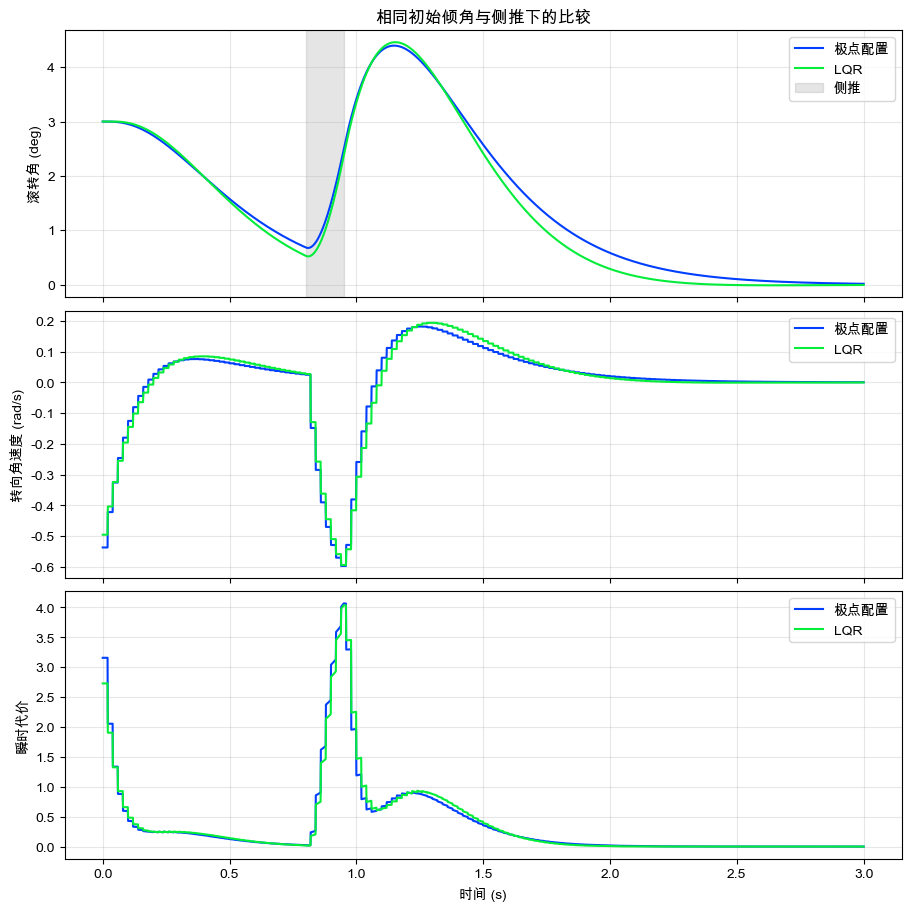

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True, constrained_layout=True)
for name, (time, states, controls, disturbances) in results.items():
    axes[0].plot(time, np.rad2deg(states[:, 1]), label=name)
    axes[1].plot(time, controls, label=name)
    state_cost = np.einsum("ni,ij,nj->n", states, Q, states)
    input_cost = R[0, 0] * controls**2
    axes[2].plot(time, state_cost + input_cost, label=name)
    print(f"{name}: max|roll|={np.max(np.abs(np.rad2deg(states[:,1]))):.3f} deg, "
          f"RMS(u)={np.sqrt(np.mean(controls**2)):.3f} rad/s, "
          f"近似 J={np.trapz(state_cost + input_cost, time):.3f}")
axes[0].axvspan(0.8, 0.95, color="gray", alpha=0.2, label="侧推")
axes[0].set_ylabel("滚转角 (deg)")
axes[0].set_title("相同初始倾角与侧推下的比较")
axes[1].set_ylabel("转向角速度 (rad/s)")
axes[2].set_ylabel("瞬时代价")
axes[2].set_xlabel("时间 (s)")
for axis in axes:
    axis.grid(True, alpha=0.3)
    axis.legend()
plt.show()


## 5. 怎样解读“最优”

LQR 的“最优”有严格但有限的含义：对给定的线性模型、给定 $Q,R$、无限时间范围、无约束连续控制，它使定义的二次型代价最小。它不自动保证：

- 在真实非线性自行车上全局最优；
- 面对饱和、时延和采样仍最优；
- 权重符合人的真实偏好；
- 对模型误差一定比所有极点配置更鲁棒。

所以 LQR 提供的是一种结构清晰、通常很好用的设计起点，而不是免调参按钮。尤其要注意：上面的比较加入了 50 Hz 采样、控制限幅、有限仿真时长和外部侧推，已经不满足连续、无约束、无限时域的标准 LQR 假设。因此，数值积分得到的有限时域代价不一定严格小于极点配置；这不是 Riccati 解失效，而是比较问题已经改变。

## 练习

1. 只把 `Q[1,1]`（滚转角权重）增大 4 倍，比较最大滚转角和控制峰值。
2. 只把 `R` 增大 10 倍，确认控制动作是否更温和。
3. 用 Bryson 权重直接运行比较实验，再解释为什么数值表现与教学权重不同。
4. 把控制限幅改成 1 rad/s。此时连续 LQR 的最优性假设被哪一条破坏？
5. 让侧推持续到仿真结束。没有积分或扰动补偿时，系统是否出现稳态偏差？
6. 下一讲会专门研究采样、执行器与噪声，因为理想线性模型稳定并不保证数字实现稳定。